# Controller comparison: cmd_vel vs odometry vs ground-truth (gz)

This notebook:
- Reads cmd_vel (geometry_msgs/Twist) and odometry (nav_msgs/Odometry) from rosbag2 (db3)
- Reads ground-truth XY from gz echo logs
- Plots per-run comparisons and an overlay comparison for noise vs no-noise

In [1]:
import os, math
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- rosbag2 helpers (cmd_vel + odom) ---
def _require_rosbag2():
    try:
        import rosbag2_py  # noqa: F401
        from rclpy.serialization import deserialize_message  # noqa: F401
        from rosidl_runtime_py.utilities import get_message  # noqa: F401
        return True, None
    except Exception as e:
        msg = (
            "rosbag2_py (and ROS 2 Python runtime) not found.\n"
            "Install ROS 2 in this container and ensure the environment is sourced, e.g.:\n"
            "  sudo apt update && sudo apt install -y ros-humble-rosbag2 ros-humble-rosbag2-storage-default-plugins\n"
            "  source /opt/ros/humble/setup.bash\n"
        )
        return False, msg + f"Original import error: {e}"

def list_bag_topics(bag_dir: str) -> Dict[str, str]:
    ok, err = _require_rosbag2()
    if not ok:
        raise RuntimeError(err)
    from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions

    reader = SequentialReader()
    storage_options = StorageOptions(uri=bag_dir, storage_id='sqlite3')
    converter_options = ConverterOptions(input_serialization_format='cdr', output_serialization_format='cdr')
    reader.open(storage_options, converter_options)

    out: Dict[str, str] = {}
    for t in reader.get_all_topics_and_types():
        out[t.name] = t.type
    return out

def _read_topic_raw(bag_dir: str, topic: str) -> List[Tuple[int, bytes]]:
    ok, err = _require_rosbag2()
    if not ok:
        raise RuntimeError(err)
    from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions, StorageFilter

    reader = SequentialReader()
    storage_options = StorageOptions(uri=bag_dir, storage_id='sqlite3')
    converter_options = ConverterOptions(input_serialization_format='cdr', output_serialization_format='cdr')
    reader.open(storage_options, converter_options)
    reader.set_filter(StorageFilter(topics=[topic]))

    out: List[Tuple[int, bytes]] = []
    while reader.has_next():
        tname, data, ts = reader.read_next()  # ts is nanoseconds
        out.append((ts, data))
    return out

def read_cmd_vel_df(bag_dir: str, topic_hint: Optional[str] = None) -> pd.DataFrame:
    ok, err = _require_rosbag2()
    if not ok:
        raise RuntimeError(err)
    from rclpy.serialization import deserialize_message
    from rosidl_runtime_py.utilities import get_message

    topics = list_bag_topics(bag_dir)
    # Pick topic by hint or by type
    topic = None
    if topic_hint and topic_hint in topics:
        topic = topic_hint
    else:
        # Prefer '/cmd_vel', else any Twist
        preferred = [k for k, t in topics.items() if t == 'geometry_msgs/msg/Twist']
        preferred.sort(key=lambda s: (0 if s.endswith('/cmd_vel') or s == '/cmd_vel' else 1, s))
        if preferred:
            topic = preferred[0]
    if not topic:
        raise RuntimeError(f"No geometry_msgs/msg/Twist topic found in bag: {topics}")

    raw = _read_topic_raw(bag_dir, topic)
    Msg = get_message('geometry_msgs/msg/Twist')
    rows = []
    t0 = raw[0][0] if raw else None
    for ts, data in raw:
        msg = deserialize_message(data, Msg)
        t = (ts - t0) * 1e-9 if t0 is not None else 0.0
        rows.append({
            't': float(t),
            'vx_cmd': float(getattr(msg.linear, 'x', np.nan)),
            'vy_cmd': float(getattr(msg.linear, 'y', np.nan)),
            'vz_cmd': float(getattr(msg.linear, 'z', np.nan)),
            'wx_cmd': float(getattr(msg.angular, 'x', np.nan)),
            'wy_cmd': float(getattr(msg.angular, 'y', np.nan)),
            'wz_cmd': float(getattr(msg.angular, 'z', np.nan)),
            'topic': topic,
        })
    return pd.DataFrame(rows)

def _quat_to_yaw(qx: float, qy: float, qz: float, qw: float) -> float:
    return math.atan2(2*(qw*qz + qx*qy), 1 - 2*(qy*qy + qz*qz))

def read_odom_df(bag_dir: str, topic_hint: Optional[str] = None) -> pd.DataFrame:
    ok, err = _require_rosbag2()
    if not ok:
        raise RuntimeError(err)
    from rclpy.serialization import deserialize_message
    from rosidl_runtime_py.utilities import get_message

    topics = list_bag_topics(bag_dir)
    topic = None
    if topic_hint and topic_hint in topics:
        topic = topic_hint
    else:
        candidates = [k for k, t in topics.items() if t == 'nav_msgs/msg/Odometry']
        # Prefer '/odom' else any
        candidates.sort(key=lambda s: (0 if s.endswith('/odom') or s == '/odom' else 1, len(s), s))
        if candidates:
            topic = candidates[0]
    if not topic:
        raise RuntimeError(f"No nav_msgs/msg/Odometry topic found in bag: {topics}")

    raw = _read_topic_raw(bag_dir, topic)
    Msg = get_message('nav_msgs/msg/Odometry')
    rows = []
    t0 = raw[0][0] if raw else None
    for ts, data in raw:
        msg = deserialize_message(data, Msg)
        t = (ts - t0) * 1e-9 if t0 is not None else 0.0
        p = msg.pose.pose.position
        q = msg.pose.pose.orientation
        v = msg.twist.twist.linear
        w = msg.twist.twist.angular
        yaw = _quat_to_yaw(q.x or 0.0, q.y or 0.0, q.z or 0.0, q.w or 1.0)
        rows.append({
            't': float(t),
            'x': float(p.x), 'y': float(p.y), 'z': float(p.z),
            'qx': float(q.x), 'qy': float(q.y), 'qz': float(q.z), 'qw': float(q.w),
            'vx': float(v.x), 'vy': float(v.y), 'vz': float(v.z),
            'wx': float(w.x), 'wy': float(w.y), 'wz': float(w.z),
            'yaw': float(yaw),
            'topic': topic,
        })
    return pd.DataFrame(rows)

In [2]:
# --- gz echo log parser for ground-truth XY (model pose) ---
import re

def read_ign_log_df(log_path: str, model_name: str = "vehicle_blue") -> pd.DataFrame:
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    name_regex = re.compile(r"^\s*name:\s*\"" + re.escape(model_name) + r"\"")
    x_regex = re.compile(r"^\s*x:\s*(-?[\d\.eE+-]+)")
    y_regex = re.compile(r"^\s*y:\s*(-?[\d\.eE+-]+)")

    xs, ys = [], []
    found_model = False
    in_position_block = False
    current_x = None

    with open(log_path, 'r') as f:
        for line in f:
            if not found_model:
                if name_regex.search(line):
                    found_model = True
                continue
            if "position {" in line:
                in_position_block = True
                current_x = None
                continue
            if in_position_block:
                mx = x_regex.search(line)
                if mx:
                    current_x = float(mx.group(1))
                    continue
                my = y_regex.search(line)
                if my and current_x is not None:
                    xs.append(current_x)
                    ys.append(float(my.group(1)))
                    # Reset for next message
                    found_model = False
                    in_position_block = False
                    current_x = None

    if not xs:
        raise RuntimeError(f"No pose messages found in log for model: {model_name}")

    df = pd.DataFrame(dict(t=np.arange(len(xs), dtype=float), x=xs, y=ys))
    return df

# NEW: robust parser for world_pose.log that also uses header stamps (sec/nsec)
def read_world_pose_log_df(log_path: str, model_name: str = "vehicle_blue") -> pd.DataFrame:
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    p_header = re.compile(r"^\s*header\s*\{")
    p_sec    = re.compile(r"^\s*sec:\s*(-?\d+)")
    p_nsec   = re.compile(r"^\s*nsec:\s*(\d+)")
    p_pose_o = re.compile(r"^\s*pose\s*\{")
    p_name   = re.compile(r'^\s*name:\s*"' + re.escape(model_name) + r'"')
    p_pos_o  = re.compile(r"^\s*position\s*\{")
    p_close  = re.compile(r"^\s*\}")
    p_x      = re.compile(r"^\s*x:\s*([-+\d.eE]+)")
    p_y      = re.compile(r"^\s*y:\s*([-+\d.eE]+)")

    cur_t_abs = None
    in_header = False
    in_pose = False
    in_position = False
    target_pose = False
    cur_x = None
    rows = []

    def fval(s: str) -> float:
        try: return float(s)
        except Exception: return float("nan")

    with open(log_path, "r") as f:
        for line in f:
            # header block (applies to following poses)
            if p_header.search(line):
                in_header = True
                sec = None; nsec = None
                continue
            if in_header:
                ms = p_sec.search(line)
                if ms: sec = int(ms.group(1)); continue
                mn = p_nsec.search(line)
                if mn: nsec = int(mn.group(1)); continue
                if p_close.search(line):
                    cur_t_abs = (float(sec) + 1e-9*float(nsec)) if (sec is not None and nsec is not None) else None
                    in_header = False
                    continue

            # pose block
            if p_pose_o.search(line):
                in_pose = True
                target_pose = False
                in_position = False
                cur_x = None
                continue
            if in_pose:
                if p_name.search(line):
                    target_pose = True
                    continue
                if p_pos_o.search(line):
                    in_position = True
                    continue
                if in_position:
                    mx = p_x.search(line)
                    if mx: cur_x = fval(mx.group(1)); continue
                    my = p_y.search(line)
                    if my and cur_x is not None:
                        x = cur_x; y = fval(my.group(1))
                        t_abs = cur_t_abs if cur_t_abs is not None else float("nan")
                        rows.append({"t_abs": t_abs, "x": x, "y": y})
                        # only one sample per pose message
                        in_position = False
                        continue
                    if p_close.search(line):
                        in_position = False
                        continue
                if p_close.search(line):
                    in_pose = False
                    continue

    if not rows:
        raise RuntimeError(f"No pose messages found in log for model: {model_name}")

    df = pd.DataFrame(rows)
    if "t_abs" in df and df["t_abs"].notna().any():
        t0 = df["t_abs"].min(skipna=True)
        df["t"] = df["t_abs"] - t0
    else:
        df["t"] = np.arange(len(df), dtype=float)
    return df

def discover_first_log(path_or_file: str) -> Optional[str]:
    if os.path.isfile(path_or_file):
        return path_or_file
    if os.path.isdir(path_or_file):
        for name in sorted(os.listdir(path_or_file)):
            if name.endswith('.log'):
                return os.path.join(path_or_file, name)
    return None

In [3]:
# --- plotting helpers ---
def plot_run_panels(run_name: str,
                    cmd_df: Optional[pd.DataFrame],
                    odom_df: Optional[pd.DataFrame],
                    gt_df: Optional[pd.DataFrame],
                    suptitle: Optional[str] = None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    # 1) XY overlay: ground-truth vs odometry
    ax = axes[0, 0]
    if gt_df is not None and not gt_df.empty:
        ax.plot(gt_df['x'], gt_df['y'], label='GT (gz)', color='tab:green', lw=1.5)
        ax.scatter(gt_df['x'].iloc[0], gt_df['y'].iloc[0], c='green', s=20)
    if odom_df is not None and not odom_df.empty:
        ax.plot(odom_df['x'], odom_df['y'], label='Odometry', color='tab:orange', lw=1.2, alpha=0.9)
        ax.scatter(odom_df['x'].iloc[0], odom_df['y'].iloc[0], c='orange', s=20)
    ax.set_title(f"{run_name}: XY path")
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(loc='best')

    # 2) vx time-series: cmd vs odom
    ax = axes[0, 1]
    if cmd_df is not None and 'vx_cmd' in cmd_df:
        ax.plot(cmd_df['t'], cmd_df['vx_cmd'], label='cmd vx', color='tab:blue', lw=1.2)
    if odom_df is not None and 'vx' in odom_df:
        ax.plot(odom_df['t'], odom_df['vx'], label='odom vx', color='tab:orange', lw=1.2)
    ax.set_title(f"{run_name}: linear x [m/s]")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('t [s]'); ax.set_ylabel('vx [m/s]')
    ax.legend(loc='best')

    # 3) wz time-series: cmd vs odom
    ax = axes[1, 0]
    if cmd_df is not None and 'wz_cmd' in cmd_df:
        ax.plot(cmd_df['t'], cmd_df['wz_cmd'], label='cmd wz', color='tab:blue', lw=1.2)
    if odom_df is not None and 'wz' in odom_df:
        ax.plot(odom_df['t'], odom_df['wz'], label='odom wz', color='tab:orange', lw=1.2)
    ax.set_title(f"{run_name}: angular z [rad/s]")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('t [s]'); ax.set_ylabel('wz [rad/s]')
    ax.legend(loc='best')

    # 4) yaw over time from odom (optional)
    ax = axes[1, 1]
    if odom_df is not None and 'yaw' in odom_df:
        ax.plot(odom_df['t'], odom_df['yaw'], label='odom yaw', color='tab:purple', lw=1.2)
    ax.set_title(f"{run_name}: yaw [rad]")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('t [s]'); ax.set_ylabel('yaw [rad]')
    ax.legend(loc='best')

    if suptitle:
        fig.suptitle(suptitle)
    plt.show()

def plot_xy_comparison(no_noise: Dict[str, pd.DataFrame], with_noise: Dict[str, pd.DataFrame]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # Left: No motion noise
    ax = axes[0]
    gt = no_noise.get('gt'); od = no_noise.get('odom')
    if gt is not None and not gt.empty:
        ax.plot(gt['x'], gt['y'], label='GT (gz)', color='tab:green')
    if od is not None and not od.empty:
        ax.plot(od['x'], od['y'], label='Odometry', color='tab:orange', alpha=0.9)
    ax.set_title('No motion noise: XY')
    ax.set_aspect('equal', adjustable='box'); ax.grid(True, alpha=0.3)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.legend(loc='best')

    # Right: With motion noise
    ax = axes[1]
    gt = with_noise.get('gt'); od = with_noise.get('odom')
    if gt is not None and not gt.empty:
        ax.plot(gt['x'], gt['y'], label='GT (gz)', color='tab:green')
    if od is not None and not od.empty:
        ax.plot(od['x'], od['y'], label='Odometry', color='tab:orange', alpha=0.9)
    ax.set_title('With motion noise: XY')
    ax.set_aspect('equal', adjustable='box'); ax.grid(True, alpha=0.3)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.legend(loc='best')

    plt.show()

In [4]:
# --- Config: set your file paths ---
base = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise"

# Rosbag2 directories (contain metadata.yaml + *.db3)
bag_no_noise = os.path.join(base, "ros2_no_noise")                   # has follow_run_0.db3
bag_with_noise = os.path.join(base, "ros2_motion_noise_test")        # has follow_run_0.db3

# Ground-truth gz logs: explicitly use world_pose.log
gt_no_noise_log = os.path.join(base, "test_run_no_motion_noise", "world_pose.log")
gt_with_noise_log = os.path.join(base, "test_run_with_noise", "world_pose.log")

# Model name inside gz pose log
model_name = "vehicle_blue"

print("Resolved paths:")
print("  bag_no_noise:", bag_no_noise)
print("  bag_with_noise:", bag_with_noise)
print("  gt_no_noise_log:", gt_no_noise_log)
print("  gt_with_noise_log:", gt_with_noise_log)

Resolved paths:
  bag_no_noise: /workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise
  bag_with_noise: /workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_test
  gt_no_noise_log: /workspaces/585_Probabilistic_Robotics/ros2_motion_noise/test_run_no_motion_noise/world_pose.log
  gt_with_noise_log: /workspaces/585_Probabilistic_Robotics/ros2_motion_noise/test_run_with_noise/world_pose.log


[INFO] [1762275441.795537804] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762275441.796902131] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762275441.817470835] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762275441.818767465] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.


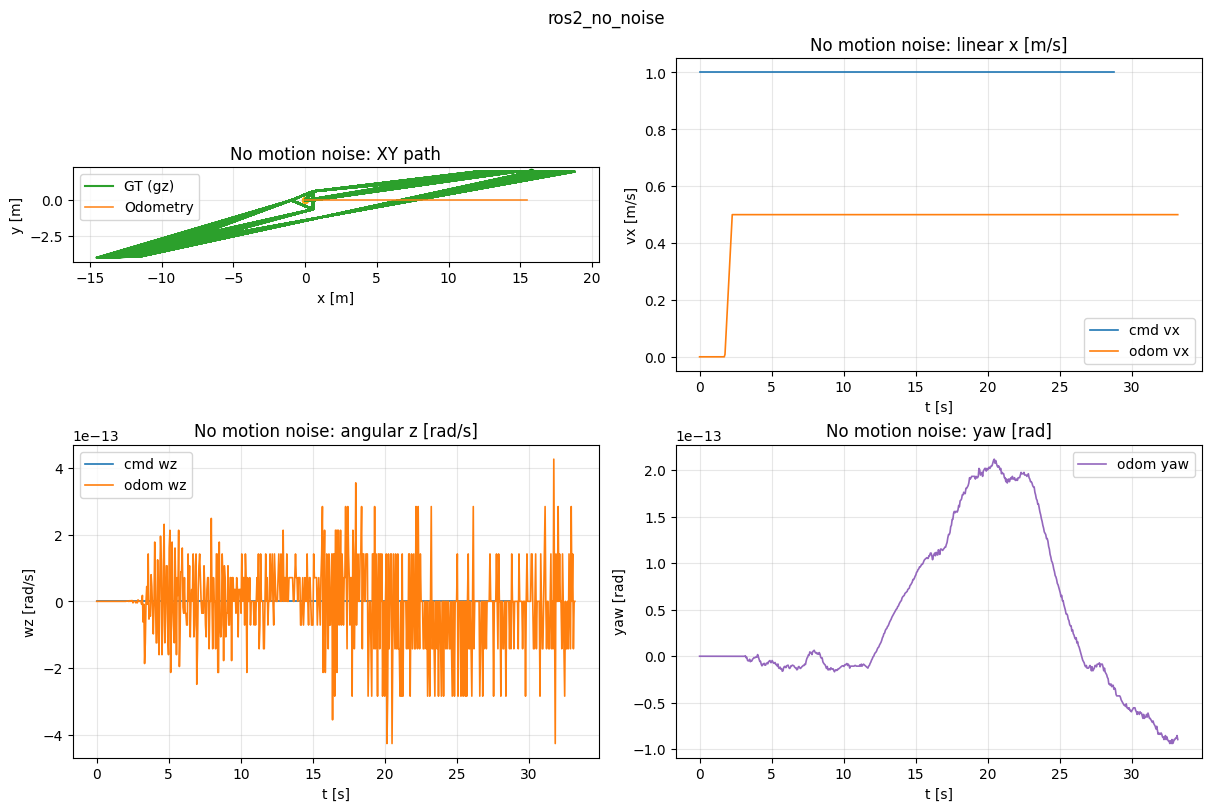

In [5]:
# --- Load and plot: no motion noise run ---
try:
    cmd_no = read_cmd_vel_df(bag_no_noise)
    odom_no = read_odom_df(bag_no_noise)
except Exception as e:
    print("Failed to read rosbag (no-noise):", e)
    cmd_no = pd.DataFrame(); odom_no = pd.DataFrame()

try:
    # use world_pose parser (with header time)
    gt_no = read_world_pose_log_df(gt_no_noise_log, model_name=model_name)
except Exception as e:
    print("Failed to read gz GT (no-noise):", e)
    gt_no = pd.DataFrame()

plot_run_panels("No motion noise", cmd_no, odom_no, gt_no,
                suptitle=os.path.basename(bag_no_noise))

[INFO] [1762275454.525117006] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_test/follow_run_0.db3' for READ_ONLY.
[INFO] [1762275454.528092802] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_test/follow_run_0.db3' for READ_ONLY.
[INFO] [1762275454.545598356] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_test/follow_run_0.db3' for READ_ONLY.
[INFO] [1762275454.547453893] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_test/follow_run_0.db3' for READ_ONLY.


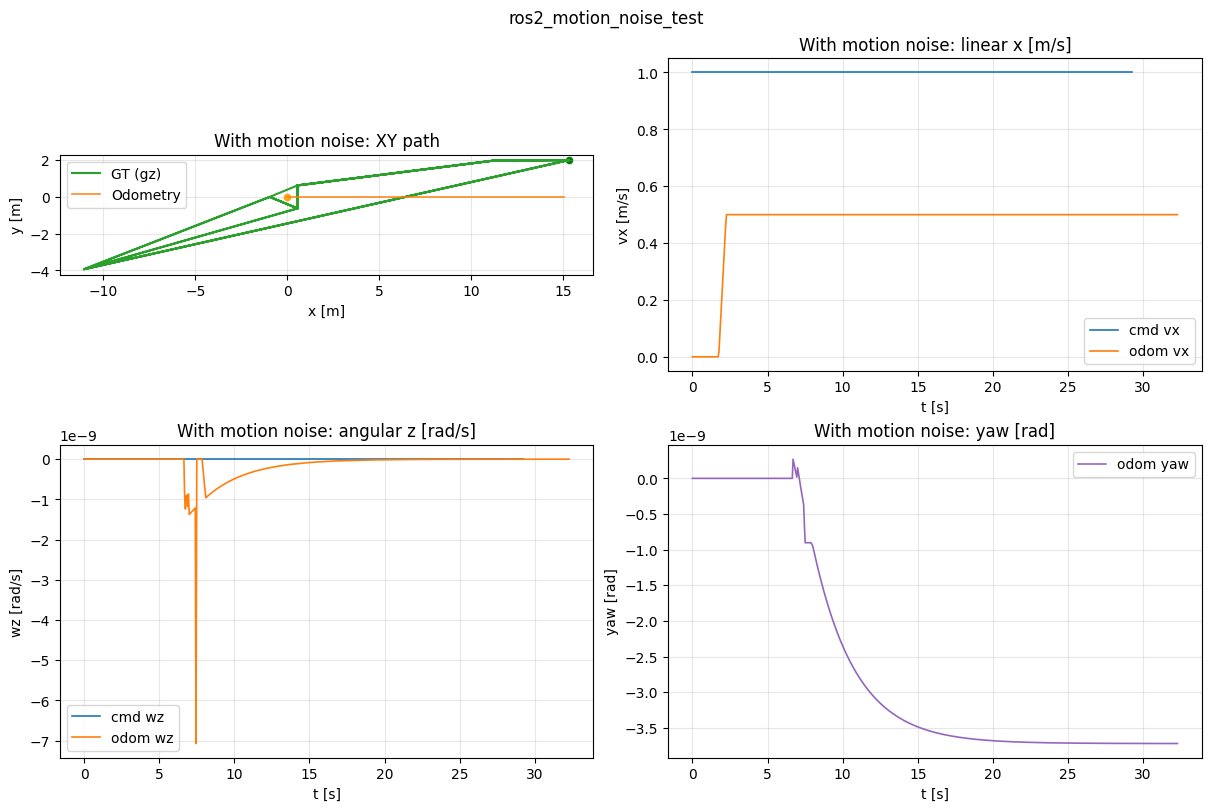

In [6]:
# --- Load and plot: with motion noise run ---
try:
    cmd_yes = read_cmd_vel_df(bag_with_noise)
    odom_yes = read_odom_df(bag_with_noise)
except Exception as e:
    print("Failed to read rosbag (with-noise):", e)
    cmd_yes = pd.DataFrame(); odom_yes = pd.DataFrame()

try:
    gt_yes = read_world_pose_log_df(gt_with_noise_log, model_name=model_name)
except Exception as e:
    print("Failed to read gz GT (with-noise):", e)
    gt_yes = pd.DataFrame()

plot_run_panels("With motion noise", cmd_yes, odom_yes, gt_yes,
                suptitle=os.path.basename(bag_with_noise))

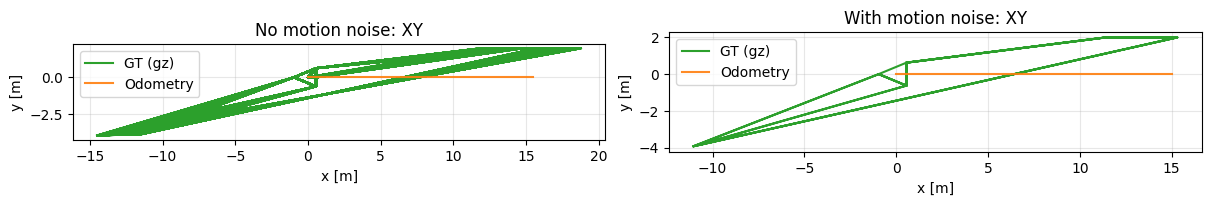

In [7]:
# --- Side-by-side XY comparison (no-noise vs with-noise) ---
no_noise = { 'gt': gt_no, 'odom': odom_no }
with_noise = { 'gt': gt_yes, 'odom': odom_yes }
plot_xy_comparison(no_noise, with_noise)

[INFO] [1762276530.451558342] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762276530.453157793] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762276530.463211837] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762276530.464481248] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_no_noise/follow_run_0.db3' for READ_ONLY.
[INFO] [1762276530.584011632] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_test/follow_run_0.db3' for READ_ONLY.
[INFO] [1762276530.585252669] [rosbag2_storage]: Opened database '/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/ros2_motion_noise_

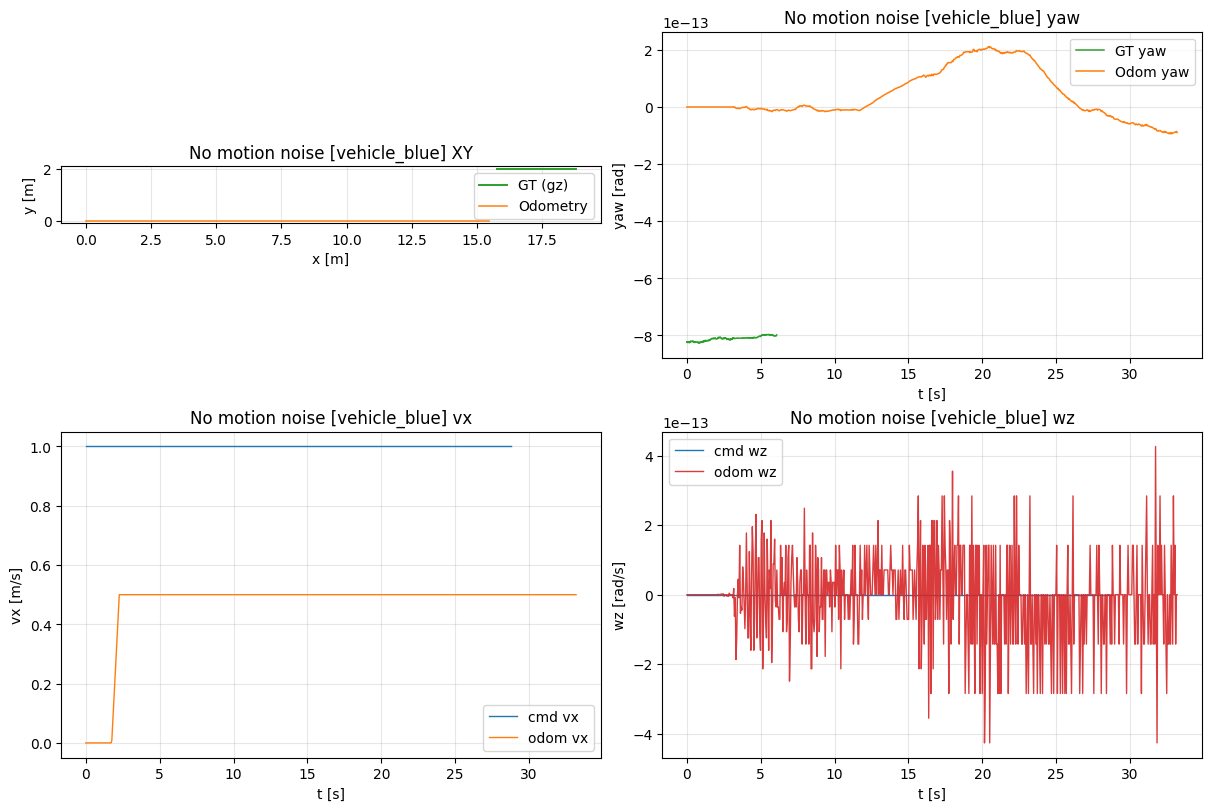

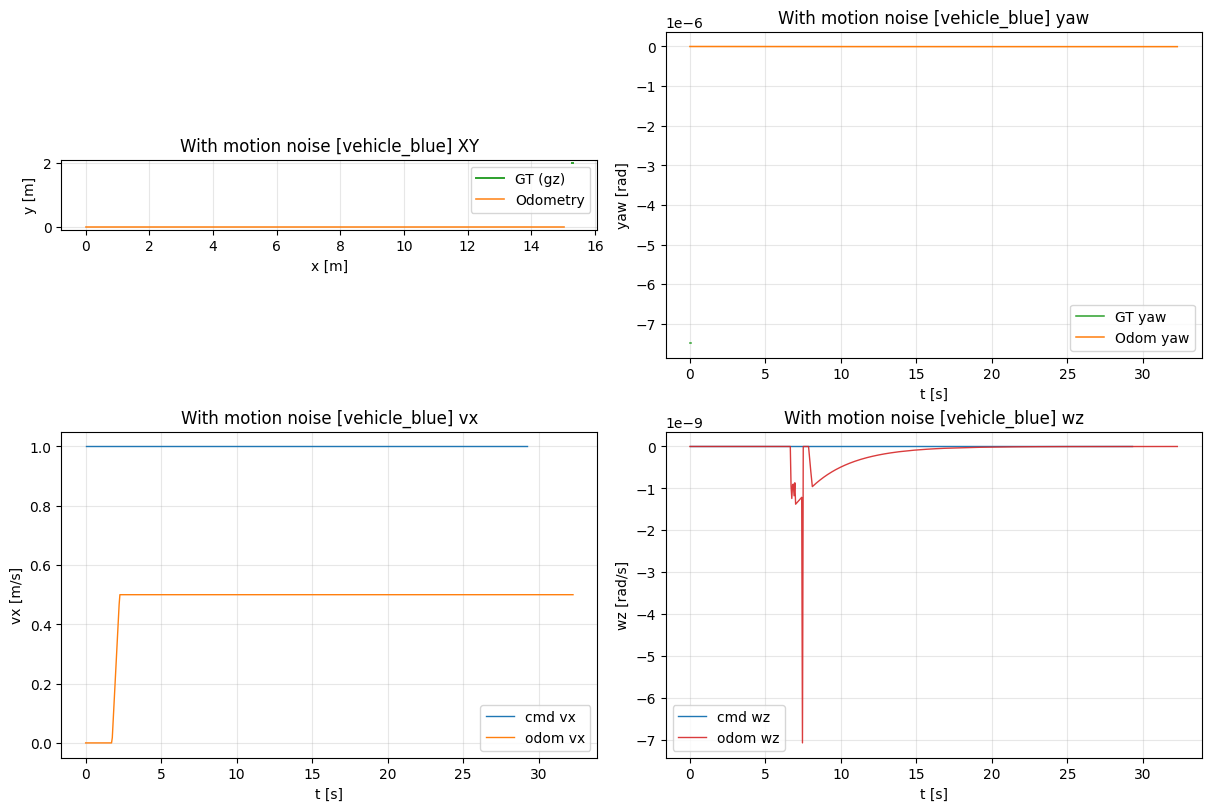

In [10]:
# --- 2D-only (x, y, yaw) investigation for selected robot (blue/green) ---

import re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Override: parse world_pose.log -> t, x, y, yaw for a specific robot
def read_world_pose_log_df(log_path: str, model_name: str = "vehicle_blue") -> pd.DataFrame:
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    p_header = re.compile(r"^\s*header\s*\{")
    p_sec    = re.compile(r"^\s*sec:\s*(-?\d+)")
    p_nsec   = re.compile(r"^\s*nsec:\s*(\d+)")
    p_pose_o = re.compile(r"^\s*pose\s*\{")
    p_name   = re.compile(r'^\s*name:\s*"' + re.escape(model_name) + r'"')
    p_pos_o  = re.compile(r"^\s*position\s*\{")
    p_ori_o  = re.compile(r"^\s*orientation\s*\{")
    p_close  = re.compile(r"^\s*\}")
    p_x      = re.compile(r"^\s*x:\s*([-+\d.eE]+)")
    p_y      = re.compile(r"^\s*y:\s*([-+\d.eE]+)")
    p_z      = re.compile(r"^\s*z:\s*([-+\d.eE]+)")
    p_w      = re.compile(r"^\s*w:\s*([-+\d.eE]+)")

    def fval(s: str) -> float:
        try: return float(s)
        except Exception: return float("nan")

    def quat_to_yaw(qx: float, qy: float, qz: float, qw: float) -> float:
        return math.atan2(2*(qw*qz + qx*qy), 1 - 2*(qy*qy + qz*qz))

    rows = []
    in_header=False; sec=None; nsec=None; cur_t_abs=None
    in_pose=False; is_target=False
    in_pos=False; in_ori=False
    px=py=None; qx=qy=qz=qw=None

    with open(log_path, "r") as f:
        for line in f:
            # header time
            if p_header.search(line):
                in_header=True; sec=None; nsec=None
                continue
            if in_header:
                ms=p_sec.search(line); mn=p_nsec.search(line)
                if ms: sec=int(ms.group(1)); continue
                if mn: nsec=int(mn.group(1)); continue
                if p_close.search(line):
                    cur_t_abs = (float(sec) + 1e-9*float(nsec)) if (sec is not None and nsec is not None) else None
                    in_header=False
                    continue

            # pose block
            if p_pose_o.search(line):
                in_pose=True; is_target=False; in_pos=False; in_ori=False
                px=py=None; qx=qy=qz=qw=None
                continue
            if in_pose:
                if p_name.search(line):
                    is_target=True; continue
                if p_pos_o.search(line):
                    in_pos=True; in_ori=False; continue
                if p_ori_o.search(line):
                    in_ori=True; in_pos=False; continue

                if in_pos:
                    mx=p_x.search(line); my=p_y.search(line)
                    if mx: px=fval(mx.group(1)); continue
                    if my: py=fval(my.group(1)); continue
                    if p_close.search(line):
                        in_pos=False; continue

                if in_ori:
                    mw=p_w.search(line); mx=p_x.search(line); my=p_y.search(line); mz=p_z.search(line)
                    if mw: qw=fval(mw.group(1)); continue
                    if mx: qx=fval(mx.group(1)); continue
                    if my: qy=fval(my.group(1)); continue
                    if mz: qz=fval(mz.group(1)); continue
                    if p_close.search(line):
                        in_ori=False; continue

                if p_close.search(line):
                    if is_target and (px is not None) and (py is not None):
                        yaw = quat_to_yaw(qx or 0.0, qy or 0.0, qz or 0.0, qw or 1.0)
                        rows.append({
                            "t_abs": cur_t_abs if cur_t_abs is not None else np.nan,
                            "x": px, "y": py, "yaw": yaw
                        })
                    in_pose=False
                    continue

    if not rows:
        raise RuntimeError(f"No pose messages found in log for model: {model_name}")

    df = pd.DataFrame(rows)
    if "t_abs" in df and df["t_abs"].notna().any():
        t0 = df["t_abs"].min(skipna=True)
        df["t"] = df["t_abs"] - t0
    else:
        df["t"] = np.arange(len(df), dtype=float)
    return df

# Select which robot to work on: "vehicle_blue" or "vehicle_green"
target_robot = "vehicle_blue"   # change to "vehicle_green" as needed

# Ensure config paths exist (fallbacks if not defined earlier in the notebook)
if "base" not in globals():
    base = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise"
if "bag_no_noise" not in globals():
    bag_no_noise = os.path.join(base, "ros2_no_noise")
if "bag_with_noise" not in globals():
    bag_with_noise = os.path.join(base, "ros2_motion_noise_test")
if "gt_no_noise_log" not in globals():
    gt_no_noise_log = os.path.join(base, "test_run_no_motion_noise", "world_pose.log")
if "gt_with_noise_log" not in globals():
    gt_with_noise_log = os.path.join(base, "test_run_with_noise", "world_pose.log")

# Topic hints (only the needed topics)
cmd_topic = f"/model/{target_robot}/cmd_vel"
odom_topic = f"/model/{target_robot}/odometry"

def _load_run(bag_dir: str, gt_log: str, robot: str):
    try:
        cmd = read_cmd_vel_df(bag_dir, topic_hint=cmd_topic)
    except Exception as e:
        print(f"cmd_vel load failed ({robot}):", e); cmd = pd.DataFrame()
    try:
        odom = read_odom_df(bag_dir, topic_hint=odom_topic)
        # Keep only 2D fields and yaw
        if not odom.empty:
            odom = odom[["t","x","y","vx","wz","yaw"]]
    except Exception as e:
        print(f"odometry load failed ({robot}):", e); odom = pd.DataFrame()
    try:
        gt = read_world_pose_log_df(gt_log, model_name=robot)
        # Keep only 2D
        if not gt.empty:
            gt = gt[["t","x","y","yaw"]]
    except Exception as e:
        print(f"GT load failed ({robot}):", e); gt = pd.DataFrame()
    return cmd, odom, gt

cmd_no, odom_no, gt_no = _load_run(bag_no_noise, gt_no_noise_log, target_robot)
cmd_yes, odom_yes, gt_yes = _load_run(bag_with_noise, gt_with_noise_log, target_robot)

def plot_robot_2d(run_name: str, cmd_df: pd.DataFrame, odom_df: pd.DataFrame, gt_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    # XY (2D)
    ax = axes[0,0]
    if not gt_df.empty:
        ax.plot(gt_df["x"], gt_df["y"], label="GT (gz)", color="tab:green", lw=1.4)
    if not odom_df.empty:
        ax.plot(odom_df["x"], odom_df["y"], label="Odometry", color="tab:orange", lw=1.2, alpha=0.9)
    ax.set_title(f"{run_name} [{target_robot}] XY")
    ax.set_aspect("equal", adjustable="box"); ax.grid(True, alpha=0.3)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.legend(loc="best")

    # Yaw vs time (2D orientation)
    ax = axes[0,1]
    if not gt_df.empty and "yaw" in gt_df:
        ax.plot(gt_df["t"], gt_df["yaw"], label="GT yaw", color="tab:green", lw=1.1)
    if not odom_df.empty and "yaw" in odom_df:
        ax.plot(odom_df["t"], odom_df["yaw"], label="Odom yaw", color="tab:orange", lw=1.1)
    ax.set_title(f"{run_name} [{target_robot}] yaw")
    ax.grid(True, alpha=0.3); ax.set_xlabel("t [s]"); ax.set_ylabel("yaw [rad]"); ax.legend(loc="best")

    # vx: cmd vs odom
    ax = axes[1,0]
    if not cmd_df.empty and "vx_cmd" in cmd_df:
        ax.plot(cmd_df["t"], cmd_df["vx_cmd"], label="cmd vx", color="tab:blue", lw=1.0)
    if not odom_df.empty and "vx" in odom_df:
        ax.plot(odom_df["t"], odom_df["vx"], label="odom vx", color="tab:orange", lw=1.0)
    ax.set_title(f"{run_name} [{target_robot}] vx")
    ax.grid(True, alpha=0.3); ax.set_xlabel("t [s]"); ax.set_ylabel("vx [m/s]"); ax.legend(loc="best")

    # wz: cmd vs odom
    ax = axes[1,1]
    if not cmd_df.empty and "wz_cmd" in cmd_df:
        ax.plot(cmd_df["t"], cmd_df["wz_cmd"], label="cmd wz", color="tab:blue", lw=1.0)
    if not odom_df.empty and "wz" in odom_df:
        ax.plot(odom_df["t"], odom_df["wz"], label="odom wz", color="tab:red", lw=1.0, alpha=0.9)
    ax.set_title(f"{run_name} [{target_robot}] wz")
    ax.grid(True, alpha=0.3); ax.set_xlabel("t [s]"); ax.set_ylabel("wz [rad/s]"); ax.legend(loc="best")

    plt.show()

plot_robot_2d("No motion noise", cmd_no, odom_no, gt_no)
plot_robot_2d("With motion noise", cmd_yes, odom_yes, gt_yes)